# Tool for Statistical Testing

This tool shows how we can apply a statistical test on two independent or two paired samples and is subdivided into the following parts:
- [Parameters](#Parameters): Parameter for the test that need to be specified (filenames, variable names, alternative).
- [Importing the Data](#Importing-the-Data): Here the needed data are imported.
- [Tests: Preliminary Code](#Tests:-Preliminary-Code): Code that need to be run before executing the statistical tests.
- [Tests for paired samples](#Tests-for-paired-samples): Use this section if your data are paired.
- [Tests for independent samples](#Tests-for-independent-samples): Use this section if your data are independent.


**General setting**

Given two methods (algorithms) **A** and **B** we have the **null hypothesis** $H_0$:

$H_0: \theta_A = \theta_B$

Here $\theta$ denotes the ground truth of a property (e.g. the expected run time or expected objective function value) of the algorithms **A** and **B**.

The **alternative hypothesis** $H_1$ depends on whether we want to apply a **two-sided** or **one-sided** test.

- **two-sided test**: Is there a statistically signifcant **difference** between **A** and **B** (e.g. **A** leads to smaller *or* greater objective function values)?
  - $H_1: \theta_A \neq \theta_B$ (```alternative = "two-sided"```)

- **one-sided test**: Does **A** or **A** lead to **better** results (e.g. smaller objective function values in minimization problems)?
  - $H_1: \theta_A > \theta_B$ (```alternative = "greater"```)
  - $H_1: \theta_A < \theta_B$ (```alternative = "less"```)


**Provided tests for two paired samples**

Two samples are **paired** (also called **related**), if the runtimes or objective function values of **A** and **B** are determined on the **same** instances.
In this case we have $n$ pairs of measurements for both algorithms.
This tool provides two statistical **tests for two paired samples**:
- **t-Test**: Applicable, if the difference of both samples is (approximately) normally distributed. Also applicable, if the sample size $n$ is large enough ($n \geq 30$) **and** the distribution is not too skewed **and** the sample (the difference) do not contain outliers.
- **Wilcoxon-Test**: Alternative, if the assumptions of the t-Test are not fulfilled.


**Provided tests for two independent samples**

Two samples are independent, if the runtimes or objective function values of **A** and **B** are determined on **different** instances. This tool provides two statistical **tests for two independent samples**:
- **t-Test**: Applicable, if the data of both samples are (approximately) normally distributed. Also applicable, if the sample size of both samples $n_A$ and $n_B$ are large enough ($n_A \geq 30$ and $n_B \geq 30$) **and** the distribution is not too skewed **and** the samples do not contain outliers. $n_A$ and $n_B$ should be (approximately) equal.
- **Wilcoxon-Test (U-Test)**: Alternative, if the assumptions of the t-Test are not fulfilled.

## Parameters

Parameters for **data import**:
- ```file_A```: Path to the file, where the results of algorithm **A** can be found.
- ```file_B```: Path to the file, where the results of algorithm **B** can be found. The results of **A** and **B** can also be contained in the same file.
- ```name_a```: Name of the column, where the results of algorithm **A** can be found.
- ```name_b```: Name of the column, where the results of algorithm **B** can be found.

Parameters for the **tests**:
- ```alternative```: Which alternative $H_1$ should be tested? ```"two-sided"```, ```"greater"``` or ```"less"``` (see above)
- ```alpha```: level of significance (usually $0.05$)

In [3]:
# --- Data (your CSV) ---
file_results = "quick_compare_results.csv"

# --- Algorithms to compare (yours) ---
alg_A = "A1_random_tabu_first"
alg_B = "A1_vnd_standard_first"

# --- Statistical parameters ---
alternative = "two-sided"
alpha = 0.05


## Importing the Data

It is assumed that the data are given in **csv-format**.
Columns are separeted by a **semicolon** ```;``` and the first row contains the **names of the variables**. Furthermore it is assumed that for decimal numbers the **decimal point** ```.``` is used.

The following example is based on ```Daten.csv``` (see TUWEL), where the results of **A** and **B** are given in the same file.
It is assumed, that this file lies in the subfolder ```data``` of this notebook.

In [4]:
import pandas as pd
import numpy as np

# 1) Load CSV file (comma-separated)
df = pd.read_csv(file_results)

# 2) Filter only the two algorithms and keep only feasible solutions
df = df[df["algorithm"].isin([alg_A, alg_B])].copy()
df = df[df["feasible"] == True].copy()

# 3) Pivot table: one row per (size, instance) and two columns (alg_A, alg_B)
#    If multiple runs exist (e.g., several seeds), keep the best one (minimum objective)
pivot = df.pivot_table(
    index=["size", "instance"],
    columns="algorithm",
    values="objective",
    aggfunc="min"
).dropna()   # keep only instances where both algorithms are present

print("Available paired comparisons (same size + instance for both):", len(pivot))
display(pivot.head())

# 4) Paired data
data_A = pivot[alg_A].to_numpy()
data_B = pivot[alg_B].to_numpy()

# 5) (Optional) quick summary
diff = data_A - data_B
print(f"Number of pairs = {len(data_A)}")
print(f"Mean objective {alg_A}: {np.mean(data_A):.4f}")
print(f"Mean objective {alg_B}: {np.mean(data_B):.4f}")
print(f"Mean difference (A - B): {np.mean(diff):.4f}  (negative => A better, since this is a minimization problem)")


Comparaciones disponibles (mismo size+instance en ambos): 9


algorithm                              A1_random_tabu_first  \
size instance                                                 
50   instance31_nreq50_nveh2_gamma50            1403.090468   
     instance32_nreq50_nveh2_gamma45            1265.703598   
     instance33_nreq50_nveh2_gamma45            1435.005777   
100  instance31_nreq100_nveh2_gamma86           2997.115207   
     instance32_nreq100_nveh2_gamma89           3359.216505   

algorithm                              A1_vnd_standard_first  
size instance                                                 
50   instance31_nreq50_nveh2_gamma50             1421.174670  
     instance32_nreq50_nveh2_gamma45             1443.423563  
     instance33_nreq50_nveh2_gamma45             1430.003946  
100  instance31_nreq100_nveh2_gamma86            3248.537773  
     instance32_nreq100_nveh2_gamma89            3479.347910

N pares = 9
Media obj A1_random_tabu_first: 4548.2408
Media obj A1_vnd_standard_first: 4576.7521
Media (A - B): -28.5113  (negativo => A mejor, porque minimizamos)


## Tests: Preliminary Code

The following packages need to be imported:

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# scipy contains statistical tests and other useful content
import scipy.stats
from scipy.stats import norm

We define some auxiliary functions:
- ```print_decision(pvalue, alpha```: Function that prints the results of a test. Input parameters:
  - ```pvalue```: the p-value of the test
  - ```alpha```: level of significance
- ```compute_pvalue```: Sometimes, statistical tests only provide two-sided p-values. In case of one-sided tests, the p-value needs to be corrected accordingly. This is what this function does. Input parameters:
  - ```pvalue```: the two-sided p-value
  - ```diff```: the difference of the sample means (*mean(data_A) - mean(data_B)*)
  - ```alternative```: either ```"two-sided"```, ```"greater"``` or ```"less"```
- ```plot_hist(data, group)```: Plots a histogram together with the estimated normal probability density curve. Input parameters:
  - ```data```: data for the histogram
  - ```group```: What is the depicted group in the plot? (used in the title)

In [6]:
def print_decision(pvalue, alpha):
    print("Test Result:")
    print("p-value = %.4f" % (pvalue))
    if pvalue < alpha:
        print("H0 can be rejected on a level of significance of " + str(alpha) + ".")
    else:
        print("H0 cannot be rejected on a level of significance of " + str(alpha) + ".")

def compute_pvalue(pvalue, diff, alternative):
    if alternative == "greater":
        if diff > 0:
            pvalue = pvalue / 2
        else:
            pvalue = 1 - pvalue / 2
    elif alternative == "less":
        if diff < 0:
            pvalue = pvalue / 2
        else:
            pvalue = 1 - pvalue / 2
    return pvalue

def plot_hist(data, group):
    # Plot a histogram
    plt.hist(data, density = True, alpha = 0.5)

    # Fit a normal distribution to the data
    mu, std = norm.fit(data)

    # Plot the probability density function
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 201)
    y = norm.pdf(x, mu, std)
    plt.plot(x, y, "black")
    title = "Fit results of " + group + ": mu = %.2f,  std = %.2f" % (mu, std)
    plt.title(title)

    plt.show()

## Tests for paired samples

Use this section if you have **two paired samples**.

### Visualisation of the distribution of the difference

We check, whether the difference ```data_A - data_B``` is (approximately) normally distributed.
This can be done by plotting a **histogram**.
Furthermore we plot the **density of an estimated normal distribution**.
If the curve approximately follows the histogram, then normal distribution can be assumed.

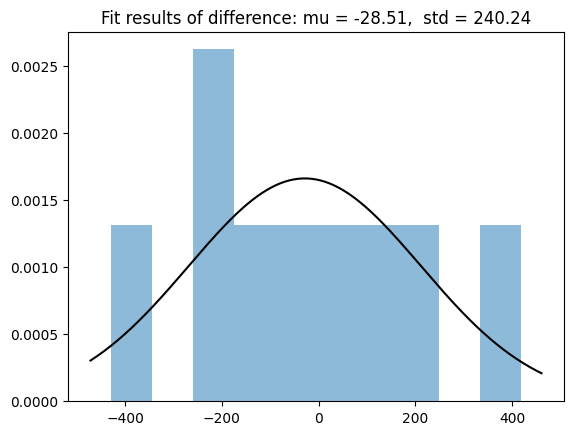

In [7]:
plot_hist(data_A - data_B, "difference")

### t-Test for two paired samples

See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

**Note**: Only the two-sided p-value is returned!

In [8]:
# Apply the statistical test
res = scipy.stats.ttest_rel(data_A, data_B)
pvalue = res.pvalue

# Compute the correct p-value (two-sided vs. one-sided)
pvalue = compute_pvalue(res.pvalue, np.mean(data_A) - np.mean(data_B), alternative)

# Print results
print_decision(pvalue, alpha)

Test Result:
p-value = 0.7457
H0 cannot be rejected on a level of significance of 0.05.


### Wilcoxon Test for two paired samples

See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

In [9]:
# Apply the statistical test
res = scipy.stats.wilcoxon(data_A, data_B, alternative = alternative)

# Print results
print_decision(res.pvalue, alpha)

Test Result:
p-value = 0.6523
H0 cannot be rejected on a level of significance of 0.05.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Load results (adjust path if needed) ---
df = pd.read_csv("quick_compare_results.csv")

A_name = "A1_random_tabu_first"
B_name = "A1_vnd_standard_first"

# Keep only feasible runs and only the two algorithms
df_ab = df[(df["feasible"] == True) & (df["algorithm"].isin([A_name, B_name]))].copy()

# Pivot to get paired objectives per instance (same instance for A and B)
pivot = df_ab.pivot_table(
    index=["size", "instance"],
    columns="algorithm",
    values="objective",
    aggfunc="mean"
).dropna()

data_A = pivot[A_name].values
data_B = pivot[B_name].values
diff = data_A - data_B  # minimization: negative => A better

n = len(diff)
mu = diff.mean()
sigma = diff.std(ddof=1)

# Paired tests
t_stat, p_t = stats.ttest_rel(data_A, data_B)
# Wilcoxon can fail if all diffs are zero; handle safely
try:
    w_stat, p_w = stats.wilcoxon(diff, zero_method="wilcox", alternative="two-sided")
except ValueError:
    w_stat, p_w = np.nan, np.nan

print(f"n = {n}")
print(f"Diff fit: mu = {mu:.2f}, std = {sigma:.2f}")
print(f"Paired t-test: t = {t_stat:.4f}, p = {p_t:.4f}")
print(f"Wilcoxon signed-rank: W = {w_stat}, p = {p_w}")

# ----------------------------
# Figure 1: Histogram of differences + fitted normal curve
# ----------------------------
plt.figure(figsize=(7,4.5))
# Histogram (density)
plt.hist(diff, bins="auto", density=True, alpha=0.6, edgecolor="black")
# Fitted normal pdf
x = np.linspace(diff.min() - 0.1*(diff.max()-diff.min()), diff.max() + 0.1*(diff.max()-diff.min()), 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma if sigma > 0 else 1.0)
plt.plot(x, pdf, linewidth=2)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(mu, linestyle=":", linewidth=2)
plt.title(f"Paired differences Δ = f_A - f_B  (A: {A_name}, B: {B_name})\n"
          f"Fit: μ={mu:.2f}, σ={sigma:.2f}")
plt.xlabel("Δ (negative means A better)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("paired_diff_hist.png", dpi=300)
plt.show()

# ----------------------------
# Figure 2: Scatter plot A vs B with diagonal y=x
# ----------------------------
plt.figure(figsize=(5.2,5.2))
plt.scatter(data_B, data_A, alpha=0.85, edgecolor="black", linewidth=0.3)
mn = min(data_A.min(), data_B.min())
mx = max(data_A.max(), data_B.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)  # y=x

plt.title("Paired objectives on test instances")
plt.xlabel("Objective of B (A1_vnd_standard_first)")
plt.ylabel("Objective of A (A1_random_tabu_first)")
plt.tight_layout()
plt.savefig("paired_scatter.png", dpi=300)
plt.show()


## Tests for independent samples

Use this section if you have **two independent samples**.

### Visualisation of the distribution of both groups

We check, whether both samples ```data_A - data_B``` are (approximately) normally distributed.
This can be done by plotting a **histogram** for each group.
Furthermore we plot the **density of an estimated normal distribution**
If the curves approximately follows the corresponding histogram, then normal distribution can be assumed.

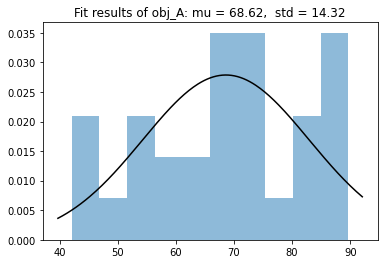

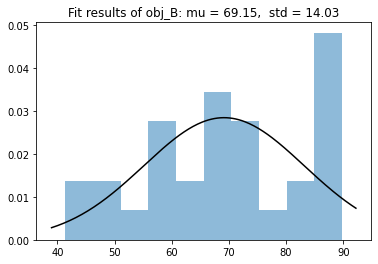

In [ ]:
plot_hist(data_A, name_A)
plot_hist(data_B, name_B)

### t-Test for two independent samples

See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

**Note**: Only the two-sided p-value is returned!

In [ ]:
# Apply the statistical test
res = scipy.stats.ttest_ind(data_A, data_B)
pvalue = res.pvalue

# Compute the correct p-value (two-sided vs. one-sided)
pvalue = compute_pvalue(res.pvalue, np.mean(data_A) - np.mean(data_B), alternative)

# Print results
print_decision(pvalue, alpha)

Test Result:
p-value = 0.8873
H0 cannot be rejected on a level of significance of 0.05.


### U-Test for two independent samples

See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

In [ ]:
# Apply the statistical test
res = scipy.stats.mannwhitneyu(data_A, data_B, alternative = alternative)

# Print results
print_decision(res.pvalue, alpha)

Test Result:
p-value = 0.8941
H0 cannot be rejected on a level of significance of 0.05.
